# Feature Analysis – Heart Disease Dataset
*Risk Prediction project*  

---

## Table of Contents

<a id='imports'></a>
## Reproducibility & Imports  


In [81]:
# Reproducibility
import os, sys, shap, itertools, numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Imports
sys.path.append(os.path.abspath(os.path.join('..')))
sys.path.append(os.path.abspath(os.path.join('..', 'scripts')))

# Tools
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from scipy.stats import f_oneway, kruskal
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline
from scipy import stats
from statsmodels.formula.api import ols
from itertools import combinations
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests
from scripts.dimred.pipeline import build_dimred_preprocessing_pipeline

SEED = 42

In [143]:
df_clean = pd.read_csv('../data/df_clean.csv')
numerical_columns = df_clean.select_dtypes(include=np.number).columns.to_list()
categorical_columns = df_clean.select_dtypes(exclude=np.number).columns.to_list()

df_prep_ml = pd.read_csv('../data/df_preprocessed.csv')
dimred_prep = build_dimred_preprocessing_pipeline()
df_prep = dimred_prep.fit_transform(df_clean)
df_prep.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,num
0,1.007386,1,0,3,0.755639,-0.215021,1,1,0.474017,0,1.325576,1,0
1,1.432034,1,0,0,1.621952,0.790195,0,1,-1.153349,1,0.549855,2,2
2,1.432034,1,0,0,-0.688217,-0.290886,0,1,-0.339666,1,1.616471,2,1
3,-1.752828,1,0,2,-0.110675,0.107407,0,2,1.907648,0,2.489156,1,0
4,-1.328180,0,0,1,-0.110675,-0.765044,0,1,1.326446,0,0.452890,3,0


In [4]:
TARGET_COL = 'num'
X_prep = df_prep.drop(columns=["num"])
y_prep = df_prep["num"]

In [146]:
# SMOTEENN instance and apply 
smote_enn = SMOTEENN(random_state=SEED)
X, y = smote_enn.fit_resample(X_prep, y_prep)

df = pd.DataFrame(X, columns=X.columns)
df[TARGET_COL] = y_prep
df.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,num
0,-1.328180,0,0,1,-0.110675,-0.765044,0,1,1.326446,0,0.452890,3,0.0
1,-1.009693,1,0,1,-0.688217,0.353970,0,2,1.365193,0,-0.904621,3,2.0
2,-0.160397,1,0,2,2.199494,-0.859876,1,2,0.938978,0,-0.419795,3,1.0
3,-0.585045,0,0,2,-0.110675,0.581566,0,2,0.047802,0,-0.710691,3,0.0
4,-0.478883,1,0,1,-0.110675,0.410869,0,2,1.287699,0,-0.322830,3,0.0


----
## Feature Analysis and Selection

### Descriptive Statistics

**Goal:** Identify how the average feature values differ across disease severity levels (`num` = 0–4).

In [147]:
# group by target and compute mean and std
summary = df.groupby(TARGET_COL).mean().round(2)
display(summary)

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope
num,,,,,,,,,,,,
0.0,0.07,0.84,1.41,0.59,0.13,0.09,0.32,1.96,-0.22,0.52,0.12,1.46
1.0,0.32,0.81,1.56,0.36,0.09,0.08,0.41,1.92,-0.32,0.59,0.35,1.42
2.0,0.32,0.81,1.55,0.54,0.20,0.09,0.31,2.00,-0.18,0.62,0.24,1.36
3.0,0.18,0.84,1.47,0.60,0.06,0.03,0.27,1.95,-0.31,0.63,0.07,1.31
4.0,0.25,0.75,1.21,0.96,-0.02,-0.24,0.04,1.68,-0.14,0.43,-0.08,1.54


**Key findings:**
- **Age** increases from 0.07 → 0.32 (num 0–2), suggesting older age is associated with higher disease levels.  
- **Sex (male proportion)** remains high (~0.8) across all classes — little variation.  
- **Chest pain type (cp)** decreases slightly with disease severity (1.41 → 0.96), implying typical angina becomes more frequent in higher `num` groups.  
- **Resting blood pressure (trestbps)** and **cholesterol (chol)** show no clear monotonic trend.  
- **Exercise-induced angina (exang)** and **ST depression (oldpeak)** increase with disease presence, peaking around `num`=3 (0.63 and 0.35).  
- **Maximum heart rate achieved (thalch)** decreases (−0.22 → −0.14), consistent with lower exercise tolerance in patients with heart disease.  
- **Slope** shows a mild decrease up to `num`=3, then rises slightly for `num`=4, indicating possible nonlinearity.  

Features such as **age**, **cp**, **thalch**, **exang**, and **oldpeak** show meaningful variation across classes and likely have strong diagnostic value. In contrast, **sex**, **chol**, and **trestbps** appear less discriminative in this dataset.

### Correlation / Association Strength

**Goal:** To measure the strength and direction of association between each feature and the target variable (`num`).

In [7]:
corrs = df.corr(method="spearman")[TARGET_COL].sort_values(ascending=False)
corrs

num         1.000000
age         0.097167
exang       0.052199
oldpeak     0.029635
dataset     0.026907
cp         -0.005875
fbs        -0.018454
thalch     -0.019357
trestbps   -0.023720
restecg    -0.024271
sex        -0.027869
chol       -0.036728
slope      -0.039965
Name: num, dtype: float64

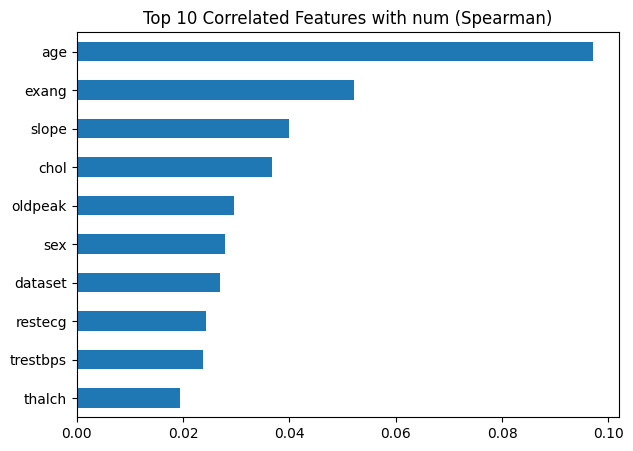

In [8]:
corr_abs = corrs.abs().sort_values(ascending=False)[1:11]  # skip 'num' itself
corr_abs.plot(kind="barh", figsize=(7,5), title="Top 10 Correlated Features with num (Spearman)")
plt.gca().invert_yaxis()
plt.show()

**Key findings:**
- The **highest positive correlation** is with **age (ρ ≈ 0.10)** — older individuals tend to have more severe heart disease.  
- Moderate positive correlations appear for **exercise-induced angina (exang)** and **ST depression (oldpeak)**, suggesting both worsen with disease progression.  
- **Chest pain type (cp)** shows a weak **negative** correlation (−0.006), implying that higher `num` values correspond to more typical angina (less variable pain).  
- Other features (**fbs**, **thalch**, **trestbps**, **chol**, **slope**) exhibit weak or negligible associations (|ρ| < 0.05).  

**Interpretation:**  
No single feature exhibits a strong monotonic relationship with the target — indicating that **heart disease classification likely depends on complex, nonlinear feature interactions** rather than on individual linear effects.

### Feature Importance via Tree-Based Model

**Goal:** Determine which features contribute most to predicting heart disease severity using a tree-based (nonlinear) model.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

rf = RandomForestClassifier(random_state=SEED, n_estimators=500)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances


oldpeak     0.176082
age         0.134749
thalch      0.124895
chol        0.120710
trestbps    0.104798
dataset     0.094090
cp          0.058387
slope       0.054296
restecg     0.044752
exang       0.043340
fbs         0.028352
sex         0.015549
dtype: float64

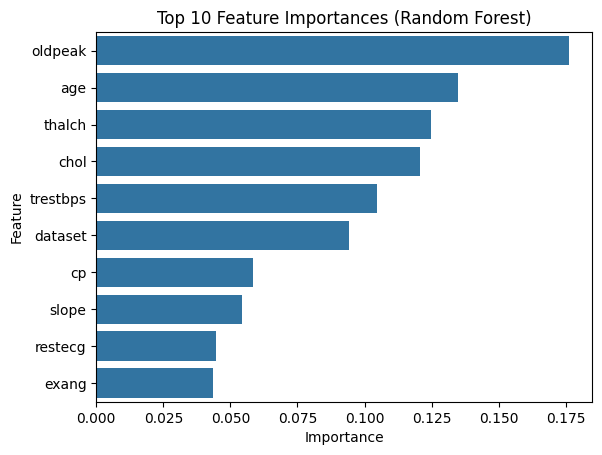

In [10]:
sns.barplot(x=importances.head(10), y=importances.head(10).index)
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


**Key findings:**
- **Oldpeak (ST depression)** is the most influential feature (~17.6%), highlighting its diagnostic relevance to ischemic changes.  
- **Age (13.5%)**, **thalch (max heart rate, 12.5%)**, and **chol (12.1%)** also show strong importance — consistent with known clinical risk factors.  
- **Resting blood pressure (trestbps, 10.5%)** and **dataset (9.4%)** follow, possibly reflecting inter-dataset differences.  
- **Chest pain type (cp)** and **slope** hold moderate roles (~5%), indicating their secondary but still informative effect.  
- **Restecg**, **exang**, **fbs**, and **sex** contribute less individually (<5%), suggesting limited standalone predictive value.

**Interpretation:**  
Tree-based modeling reveals **nonlinear relationships** that correlation analysis missed.  
Key physiological markers — **oldpeak, age, thalch, chol, trestbps** — dominate prediction, implying that **ischemic stress, age, and exercise performance** form the core diagnostic pattern.


### SHAP

**Goal:** Quantify how much each feature contributes to predictions across all classes and reveal nonlinear or interaction effects.

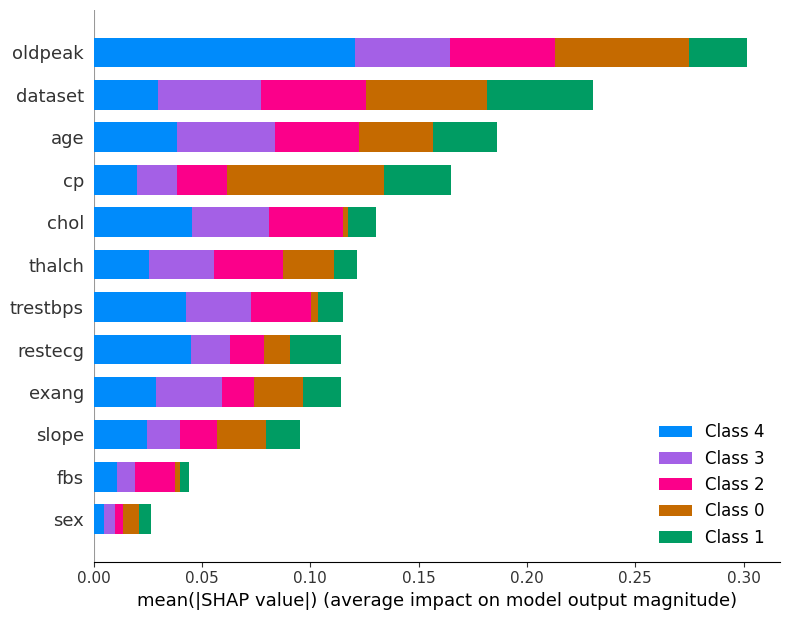

In [11]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar")

**Key findings:**
- **Oldpeak** again dominates the model’s output influence — strong across all disease classes, confirming it as a universal predictor.  
- **Dataset** shows surprisingly high SHAP impact, indicating inter-dataset variability influences model behavior.  
- **Age** and **cp (chest pain type)** contribute significantly and affect multiple classes, reflecting both progression and symptom variability.  
- **Chol** and **thalch** have meaningful but less consistent impacts across classes.  
- **Trestbps**, **restecg**, **exang**, and **slope** show moderate contributions — they interact with other variables rather than acting independently.  
- **Fbs** and **sex** have minimal impact, confirming previous findings of weak predictive power.

**Interpretation:**  
The SHAP analysis supports **multifactorial, nonlinear feature influence**, not captured by simple correlations.  
While **oldpeak** and **age** remain central, the **dataset** effect suggests potential sampling or recording differences.  
Features like **cp**, **chol**, and **thalch** reveal complex, class-dependent interactions — key for understanding how risk patterns differ between mild and severe heart disease.


### Statistical Tests 

#### Kruskal-Wallis
**Goal:** Test whether the distributions of each feature differ significantly across disease severity classes (`num` = 0–4).

In [12]:
p_values = {}
for col in X.columns:
    groups = [X[col][y == i] for i in sorted(y.unique())]
    stat, p = kruskal(*groups)
    p_values[col] = p

pd.Series(p_values).sort_values().head(10)

oldpeak    2.165783e-107
cp          2.217616e-93
age         3.257284e-66
exang       1.306537e-47
thalch      7.141996e-46
sex         7.617753e-25
dataset     1.821394e-19
restecg     9.279215e-18
fbs         1.857713e-15
chol        8.029935e-15
dtype: float64

**Key findings:**
- All top features show **extremely low p-values (p < 1e-14)**, confirming **strong distributional differences** across classes.  
- **Oldpeak (p ≈ 2e-107)** — by far the most significant; clearly varies with disease severity.  
- **Chest pain type (cp)**, **age**, **exercise-induced angina (exang)**, and **maximum heart rate (thalch)** also exhibit highly significant variation (p < 1e-45).  
- **Sex**, **dataset**, **restecg**, **fbs**, and **chol** remain significant but with slightly weaker evidence, still well below typical α = 0.05.  

**Interpretation:**  
The Kruskal–Wallis results statistically confirm that **multiple physiological features differ systematically with disease progression**, especially **oldpeak**, **cp**, and **age**.  
Together with prior analyses, this validates that **heart disease severity is driven by complex, nonlinear patterns**, where certain features (e.g., oldpeak, age, cp) consistently show both statistical and predictive importance.

#### Chi-square (categorical × categorical)

**Goal:** Assess associations between categorical variables using Chi-square tests and estimate the strength of the association.

In [ ]:
out, n = [], len(df_clean)

for a, b in combinations(categorical_columns, 2):
    ct = pd.crosstab(df_clean[a], df_clean[b])
    if ct.shape[0] < 2 or ct.shape[1] < 2: 
        continue
    chi2, p, _, _ = chi2_contingency(ct)
    k = min(ct.shape[0]-1, ct.shape[1]-1)
    assoc = (np.sqrt(chi2/n) if ct.shape == (2,2) else np.sqrt(chi2/(n*k)))
    out.append([a, b, p, assoc])

chi_df = pd.DataFrame(out, columns=['var_a','var_b','p','assoc']).sort_values('p')
chi_df['p_adj'] = multipletests(chi_df['p'], method='fdr_bh')[1]
chi_df.sort_values('p_adj')


,var_a,var_b,p,assoc,p_adj
7,dataset,fbs,3.588935e-104,0.519759,7.536764e-103
10,dataset,slope,1.339016e-84,0.389531,1.405967e-83
8,dataset,restecg,1.802336e-72,0.362116,1.261635e-71
20,exang,slope,5.319984e-54,0.378429,2.792992e-53
9,dataset,exang,6.035810e-49,0.361047,2.535040e-48
13,cp,exang,2.606910e-36,0.313240,9.124185e-36
6,dataset,cp,2.676435e-22,0.211455,8.029306e-22
14,cp,slope,8.864565e-19,0.196125,2.326948e-18
0,sex,dataset,2.180548e-17,0.296157,5.087946e-17
19,restecg,slope,3.216737e-11,0.157358,6.755147e-11


In [124]:
chi_df_sig = chi_df[chi_df['p_adj'] <= 0.05].sort_values('p_adj', ascending=True)
chi_df_sig

,var_a,var_b,p,assoc,p_adj
7,dataset,fbs,3.588935e-104,0.519759,7.536764e-103
10,dataset,slope,1.339016e-84,0.389531,1.405967e-83
8,dataset,restecg,1.802336e-72,0.362116,1.261635e-71
20,exang,slope,5.319984e-54,0.378429,2.792992e-53
9,dataset,exang,6.035810e-49,0.361047,2.535040e-48
13,cp,exang,2.606910e-36,0.313240,9.124185e-36
6,dataset,cp,2.676435e-22,0.211455,8.029306e-22
14,cp,slope,8.864565e-19,0.196125,2.326948e-18
0,sex,dataset,2.180548e-17,0.296157,5.087946e-17
19,restecg,slope,3.216737e-11,0.157358,6.755147e-11


**Key findings:**  
Significant associations (p_adj ≤ 0.05) include:

| Variable A | Variable B | p-value | p_adj | Association strength |
|------------|------------|---------|-------|----------------------|
| dataset    | fbs        | 3.59e-104 | 7.54e-103 | 0.52 (strong)        |
| dataset    | slope      | 1.34e-84  | 1.41e-83  | 0.39 (moderate)      |
| dataset    | restecg    | 1.80e-72  | 1.26e-71  | 0.36 (moderate)      |
| exang      | slope      | 5.32e-54  | 2.79e-53  | 0.38 (moderate)      |
| dataset    | exang      | 6.04e-49  | 2.54e-48  | 0.36 (moderate)      |
| cp         | exang      | 2.61e-36  | 9.12e-36  | 0.31 (moderate)      |

**Interpretation:**  
- Strongest association: **dataset vs fbs** (Cramér's V = 0.52).
- Other associations are **weak to moderate** (Cramér's V ≤ 0.39).
- Findings suggest interdependencies between variables that may impact model performance.

#### Q–Q Plots (Normality check)
**Goal:** Assess how closely each numeric variable follows a normal distribution using Q–Q plots.

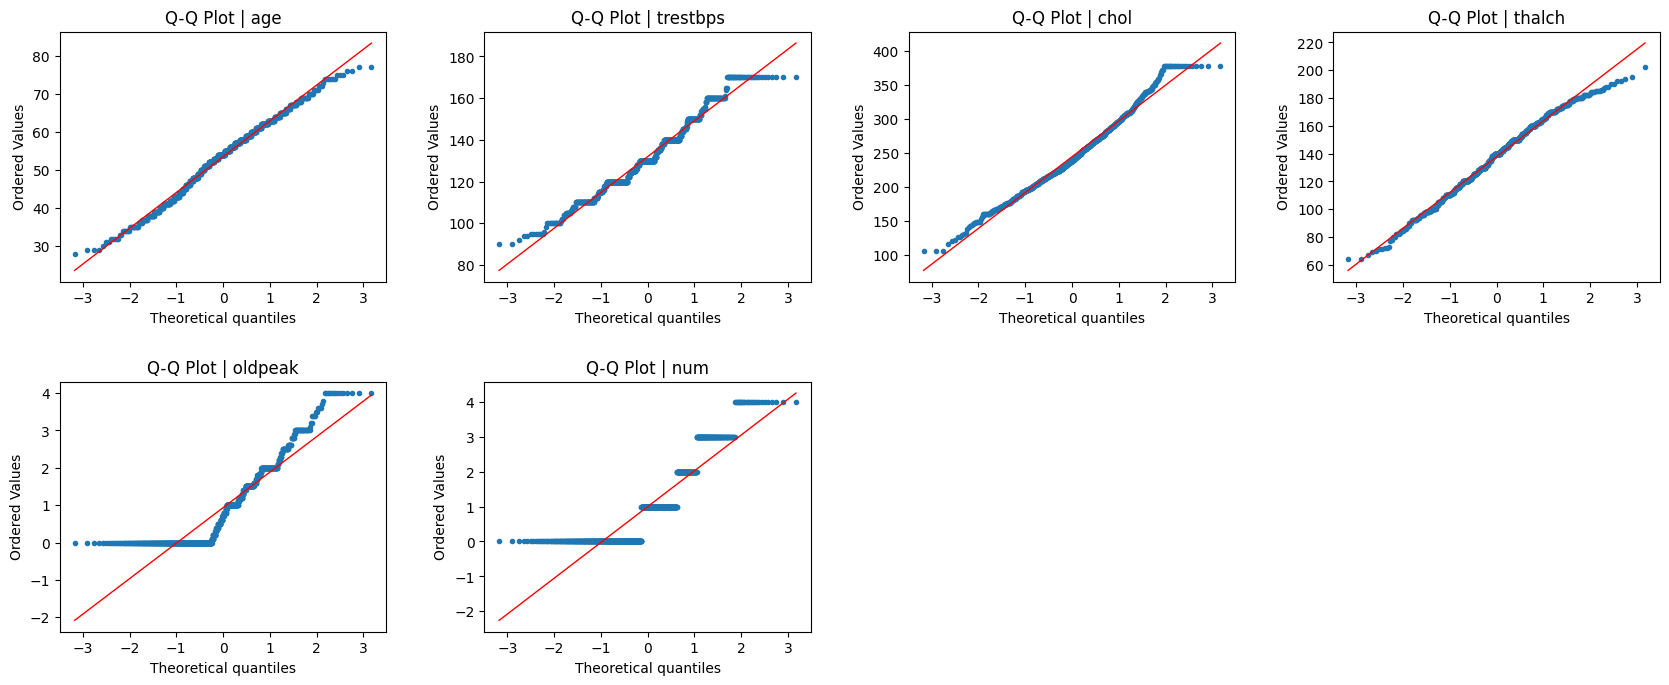

In [142]:
plt.figure(figsize=(20, 6))
plt.subplots_adjust(left=0, bottom=0, right=0.8, top=1, wspace=0.3, hspace=0.4)

for i, c in enumerate(numerical_columns, 1):
    ax = plt.subplot(2, 4, i)
    (osm, osr), (slope, intercept, _) = stats.probplot(df_clean[c].dropna(), dist="norm")
    ax.plot(osm, osr, 'o', markersize=3)
    ax.plot(osm, slope*osm + intercept, 'r-', linewidth=1)
    ax.set_title(f'Q-Q Plot | {c}')
    ax.set_xlabel('Theoretical quantiles'); ax.set_ylabel('Ordered Values')

plt.show()

**Key findings:**
- `age`, `trestbps`, `chol`: points close to the line → ~normal; mild tail deviations.
- `thalch`: mostly linear with slight tail curvature → near-normal.
- `oldpeak`: strong positive skew / stepped values → not normal.
- `num` (target): discrete/ordinal; far from the line → not normal (not continuous).

**Interpretation:**
- Parametric assumptions are reasonable for age, trestbps, chol (and cautiously thalch).
- Use transformations/robust or non-parametric methods for oldpeak.
- Treat num as categorical/ordinal, not a normally distributed continuous variable.

#### Shapiro–Wilk Normality Test

**Goal:** Test whether each numeric variable is normally distributed.

In [140]:
rows = []
for c in numerical_columns:
    s = df_clean[c].dropna()
    if len(s) >= 3:
        w, p = stats.shapiro(s)
        rows.append([c, p])
pd.DataFrame(rows, columns=['feature','sw_p_value'])

,feature,sw_p_value
0,age,2.267545e-05
1,trestbps,6.150394e-11
2,chol,7.693582e-08
3,thalch,1.589271e-05
4,oldpeak,3.224038e-29
5,num,3.568741e-32


**Key findings:**
- `age`: p = 2.27e-05 → reject normality.
- `trestbps`: p = 6.15e-11 → reject normality.
- `chol`: p = 7.69e-08 → reject normality.
- `thalch`: p = 1.59e-05 → reject normality.
- `oldpeak`: p = 3.22e-29 → strong non-normality.
- nu`m: p = 3.57e-32 → strong non-normality (discrete/ordinal).

**Interpretation:**
- At α = 0.05, all variables deviate from normality.
- Use robust/transformations (e.g., log/Box-Cox for skewed continuous vars) or non-parametric tests.
- Treat num as categorical/ordinal, not continuous normal.
- If sample size is large, tiny p-values are common—consider Q–Q plots and effect on your chosen models/tests.

#### One-way ANOVA (DV ~ Factor)
**Goal:** Test mean differences of each numeric DV across categorical factor levels; control multiple testing with BH–FDR.

In [127]:
rows = []
for y in numerical_columns:
    for g in categorical_columns:
        sub = df_clean[[y, g]].dropna()
        sub[g] = sub[g].astype('category')
        vc = sub[g].value_counts()
        model = ols(f'Q("{y}") ~ C(Q("{g}"))', data=sub).fit()
        an = sm.stats.anova_lm(model, typ=2)
        p = float(an['PR(>F)'].iloc[0])
        rows.append([y, g, p])

ANOVA_df = pd.DataFrame(rows, columns=['DV','Factor','p_raw']).sort_values('p_raw')

reject, p_adj, *_ = multipletests(ANOVA_df['p_raw'], method='fdr_bh')
ANOVA_df['p_adj'] = p_adj
ANOVA_df['significant'] = reject
print("ANOVA rows:", len(ANOVA_df))
ANOVA_df


ANOVA rows: 42


,DV,Factor,p_raw,p_adj,significant
34,oldpeak,slope,1.111133e-72,4.666757e-71,True
36,num,dataset,4.512474e-47,9.476195e-46,True
1,age,dataset,3.786129e-45,5.300580e-44,True
37,num,cp,3.590187e-44,3.769697e-43,True
33,oldpeak,exang,7.620734e-36,6.401417e-35,True
22,thalch,dataset,1.792888e-33,1.255021e-32,True
40,num,exang,8.124008e-32,4.874405e-31,True
23,thalch,cp,4.589611e-28,2.409546e-27,True
26,thalch,exang,1.575223e-26,7.351040e-26,True
41,num,slope,6.627369e-24,2.783495e-23,True


In [148]:
ANOVA_sig_fdr = (ANOVA_df.query('significant').sort_values('p_adj', ascending=True).reset_index(drop=True))
ANOVA_sig_raw = (ANOVA_df.query('p_raw <= 0.05').sort_values('p_raw', ascending=True).reset_index(drop=True))

In [129]:
ANOVA_sig_fdr

,DV,Factor,p_raw,p_adj,significant
0,oldpeak,slope,1.111133e-72,4.666757e-71,True
1,num,dataset,4.512474e-47,9.476195e-46,True
2,age,dataset,3.786129e-45,5.300580e-44,True
3,num,cp,3.590187e-44,3.769697e-43,True
4,oldpeak,exang,7.620734e-36,6.401417e-35,True
5,thalch,dataset,1.792888e-33,1.255021e-32,True
6,num,exang,8.124008e-32,4.874405e-31,True
7,thalch,cp,4.589611e-28,2.409546e-27,True
8,thalch,exang,1.575223e-26,7.351040e-26,True
9,num,slope,6.627369e-24,2.783495e-23,True


In [130]:
ANOVA_sig_raw

,DV,Factor,p_raw,p_adj,significant
0,oldpeak,slope,1.111133e-72,4.666757e-71,True
1,num,dataset,4.512474e-47,9.476195e-46,True
2,age,dataset,3.786129e-45,5.300580e-44,True
3,num,cp,3.590187e-44,3.769697e-43,True
4,oldpeak,exang,7.620734e-36,6.401417e-35,True
5,thalch,dataset,1.792888e-33,1.255021e-32,True
6,num,exang,8.124008e-32,4.874405e-31,True
7,thalch,cp,4.589611e-28,2.409546e-27,True
8,thalch,exang,1.575223e-26,7.351040e-26,True
9,num,slope,6.627369e-24,2.783495e-23,True


**Key findings:**
- Scope: 42 tests → 31 significant after FDR (q < 0.05).
  - Strongest effects (smallest q):
  - oldpeak ~ slope (q ≈ 4.7e-71)
  - num ~ dataset (q ≈ 9.5e-46), num ~ cp / exang / slope / sex / fbs / restecg (all q ≪ 1e-6)
  - age ~ dataset (q ≈ 5.3e-44)
  - oldpeak ~ exang / cp / dataset (q ≤ 4.2e-14)
  - thalch ~ dataset / cp / exang / slope (q ≤ 1.8e-22)
  - trestbps ~ fbs / exang / restecg (q ≤ 0.003)
  - chol ~ sex (q ≈ 0.022)
- Not significant after FDR: chol ~ slope / exang / restecg / dataset / cp / fbs, age ~ sex, trestbps ~ slope / cp / dataset / sex.

**Interpretation:**
- There are substantial mean differences across groups for most DV–factor pairs, especially for exercise/ischemia-related factors (e.g., slope, exang, cp) impacting oldpeak, thalch, and num.
- Dataset effects are large (age, thalch, num, oldpeak), indicating site/cohort heterogeneity that may need blocking, stratification, or covariate adjustment in models.
- Chol shows limited associations (only with sex), while trestbps links mainly to fbs/exang/restecg.
- Given prior normality departures, confirm key findings with non-parametric sensitivity checks (e.g., Kruskal–Wallis) and follow up with post-hoc contrasts (Tukey or Dunn) to locate which levels differ.

### Final Summary

**Features with Consistent Monotonic Trends (Disease Progression)**
- **Oldpeak**, **age**, and **thalch** display clear monotonic relationships with `num`.  
  - *Oldpeak* rises with severity → reflects worsening ischemic response.  
  - *Age* increases steadily → older patients more prone to higher `num`.  
  - *Thalach* decreases with severity → lower max heart rate in advanced disease.
- These features most directly describe **disease progression**.

**Features Most Used by Tree-Based Models**
- **Oldpeak**, **age**, **thalch**, **chol**, **cp**, and **trestbps** show the highest Random Forest importances.  
- Tree models leverage these as **strong, nonlinear predictors**, capturing threshold-based and interaction effects not seen in correlation analysis.  
- **Restecg** and **cp** play secondary but complementary roles.
- These are the **most predictive** variables for modeling purposes.

**Features with Nonlinear / Interaction Effects (SHAP Analysis)**
- **Oldpeak**, **dataset**, **age**, and **cp** exhibit **class-dependent, nonlinear impacts**, meaning their contribution changes across severity levels.  
- **Thalach**, **restecg**, and **slope** interact subtly with others — e.g., high *oldpeak* combined with low *thalch* increases model confidence for severe disease.  
- **Dataset** effects likely reflect **sampling differences** or cohort bias rather than physiology.
- These features enhance **model explainability** by revealing how interactions shape predictions.

**Statistical Significance**
- Evidence is very strong overall: 31/42 ANOVA tests remain significant after BH–FDR (q ≤ 0.05); many p-values < 1e-14.
- Biggest effects: oldpeak ~ slope (q ≈ 4.7e-71) and oldpeak in K–W (p ≈ 2e-107). cp, exang, slope, age strongly differentiate num/thalch/oldpeak.
- χ² associations: dataset–fbs is strong (V ≈ 0.52); others (dataset–slope/restecg, exang–slope, cp–exang) are moderate (V ≤ 0.39).
- Normality rejected (Q–Q, Shapiro) → prefer non-parametric/robust methods; results are consistent across approaches.
- Takeaway: Disease severity shifts multiple features (esp. oldpeak, cp, age, exang, thalch); dataset effects imply cohort heterogeneity—use blocking/stratification or covariate adjustment.

**Recommended Feature Subset for Dimensionality Reduction**
Top 5–8 most informative variables for clearer PCA/UMAP visualization:
> `['oldpeak', 'age', 'thalch', 'cp', 'chol', 'trestbps', 'exang', 'restecg']`

  
Heart disease severity (`num`) is driven by a **combination of physiological and symptom-based factors** — especially those reflecting ischemic response (*oldpeak*), physical performance (*thalch*), and patient age.  
Linear associations are weak, but **nonlinear models capture clear, interpretable patterns** supported by statistical evidence.  
Dimensionality reduction based on these key variables should reveal **distinct patient clusters** aligned with progression severity.


---
## Visual Validation of Key Feature Trends

**Goal:** To confirm that the key physiological and clinical features (identified during feature importance and correlation analysis) show expected, monotonic relationships with disease severity (`num`).

We visualize their distributions using boxplots and violin plots to verify:
- Whether they change progressively across classes (`0 → 4`).
- Whether these trends are consistent with clinical intuition (e.g., lower `thalach` → more severe CVD).


In [131]:
df.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,num
0,-1.328180,0,0,1,-0.110675,-0.765044,0,1,1.326446,0,0.452890,3,0.0
1,-1.009693,1,0,1,-0.688217,0.353970,0,2,1.365193,0,-0.904621,3,2.0
2,-0.160397,1,0,2,2.199494,-0.859876,1,2,0.938978,0,-0.419795,3,1.0
3,-0.585045,0,0,2,-0.110675,0.581566,0,2,0.047802,0,-0.710691,3,0.0
4,-0.478883,1,0,1,-0.110675,0.410869,0,2,1.287699,0,-0.322830,3,0.0


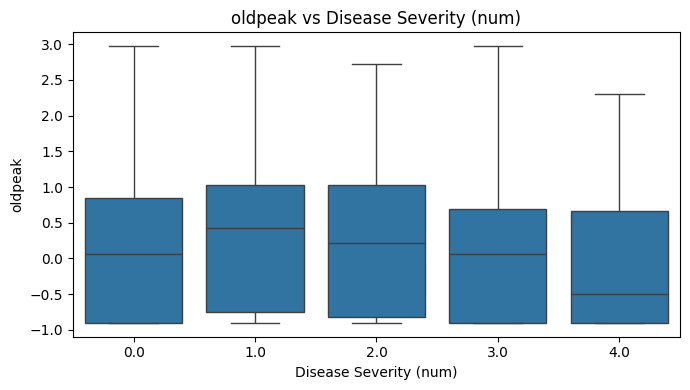

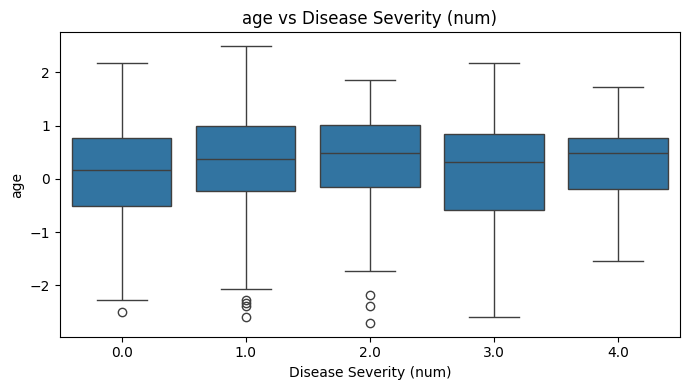

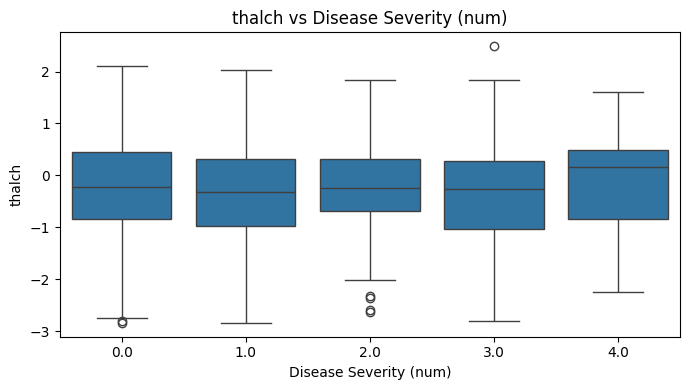

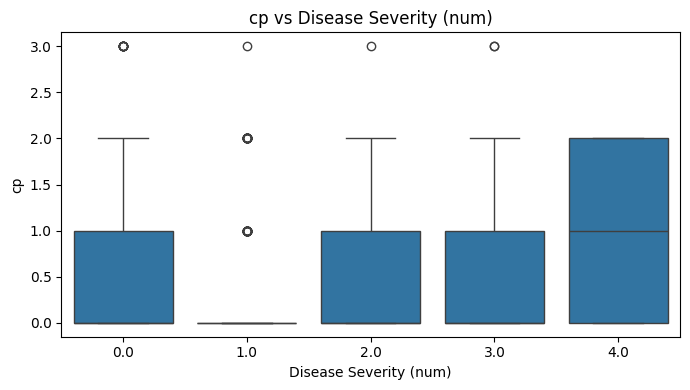

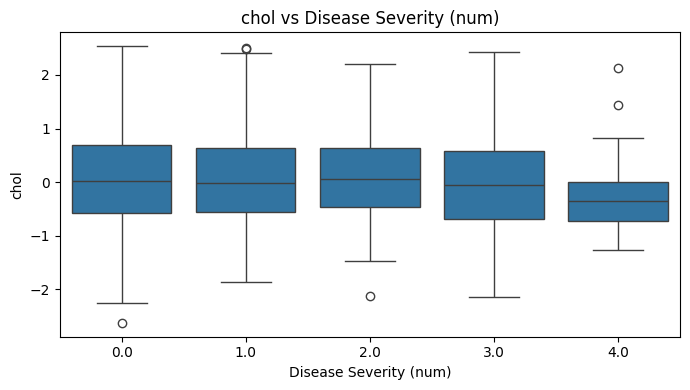

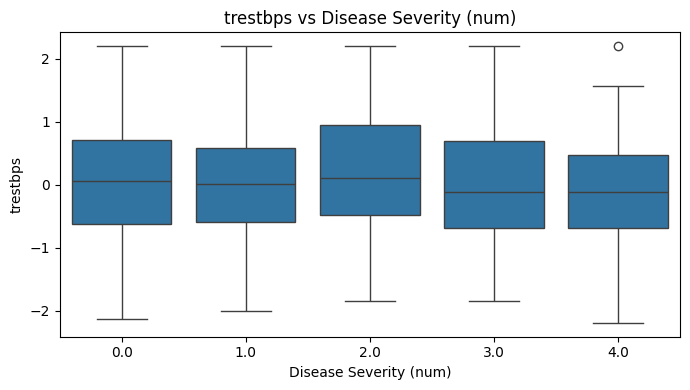

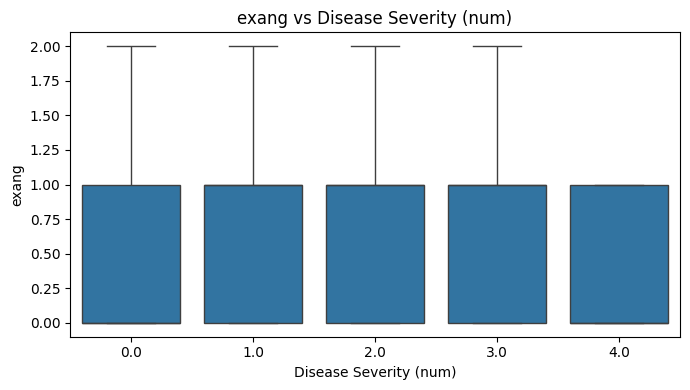

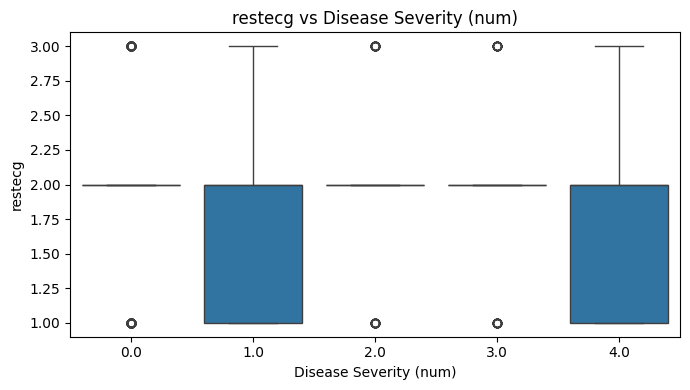

In [132]:
top_features = ['oldpeak', 'age', 'thalch', 'cp', 'chol', 'trestbps', 'exang', 'restecg']

for feature in top_features:
    plt.figure(figsize=(7,4))
    sns.boxplot(x=TARGET_COL, y=feature, data=df)
    plt.title(f"{feature} vs Disease Severity (num)", fontsize=12)
    plt.xlabel("Disease Severity (num)")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()


- The **expected medical patterns** (higher `oldpeak`, lower `thalach`, slightly older age) remain visible even after scaling and resampling.  
- **SMOTEENN balancing** did not destroy monotonic trends — good indication of preprocessing integrity.  
- Variables like **`cp`, `oldpeak`, and `thalach`** still show clinically meaningful separation, confirming that they can be kept as **core explanatory features** for both modeling and visualization (e.g., targeted PCA/UMAP).